# 3D plot of neurons in the philshiu/Drosophila_brain_model

The model at https://github.com/philshiu/Drosophila_brain_model addresses neurons by their **FlyWire root_id** but does not ship coordinates. This notebook fetches:

1. The model's neuron list — `Completeness_783.csv` from the Drosophila_brain_model repo (138 639 root_ids).
2. Per-neuron coordinates — `Supplemental_file1_neuron_annotations.tsv` from `flyconnectome/flywire_annotations` (139 244 rows, FlyWire 783 release).

It joins them on `root_id`, converts the voxel coordinates (4×4×40 nm) to micrometres, and plots the soma positions in 3D, colour-coded by super-class.

Files are cached to `~/.cache/flywire_783/` so re-runs are fast.

In [1]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CACHE = Path.home() / ".cache" / "flywire_783"
CACHE.mkdir(parents=True, exist_ok=True)

SOURCES = {
    "completeness_783.csv": (
        "https://raw.githubusercontent.com/philshiu/"
        "Drosophila_brain_model/main/Completeness_783.csv"
    ),
    "flywire_annotations_783.tsv": (
        "https://raw.githubusercontent.com/flyconnectome/"
        "flywire_annotations/main/supplemental_files/"
        "Supplemental_file1_neuron_annotations.tsv"
    ),
}


def fetch(name: str) -> Path:
    path = CACHE / name
    if not path.exists():
        print(f"downloading {name} ...")
        urllib.request.urlretrieve(SOURCES[name], path)
    print(f"{name}: {path.stat().st_size / 1e6:.1f} MB")
    return path


model_csv = fetch("completeness_783.csv")
annot_tsv = fetch("flywire_annotations_783.tsv")

downloading completeness_783.csv ...


completeness_783.csv: 3.3 MB
downloading flywire_annotations_783.tsv ...


flywire_annotations_783.tsv: 32.6 MB


In [2]:
model_ids = pd.read_csv(model_csv).rename(columns={"Unnamed: 0": "root_id"})[["root_id"]]
annot = pd.read_csv(annot_tsv, sep="\t", low_memory=False)

df = model_ids.merge(
    annot[
        [
            "root_id",
            "pos_x", "pos_y", "pos_z",
            "soma_x", "soma_y", "soma_z",
            "super_class", "side", "top_nt",
        ]
    ],
    on="root_id",
    how="inner",
)

# Prefer soma position; fall back to the anchor (pos_*) when no nucleus was identified.
for axis in ("x", "y", "z"):
    df[axis] = df[f"soma_{axis}"].fillna(df[f"pos_{axis}"])

# voxel space (4, 4, 40) nm -> micrometres
df["x_um"] = df["x"] * 4 / 1000
df["y_um"] = df["y"] * 4 / 1000
df["z_um"] = df["z"] * 40 / 1000

print(f"model neurons:        {len(model_ids):,}")
print(f"matched in annotations: {len(df):,} ({len(df) / len(model_ids):.1%})")
print(f"with soma coordinates:  {df['soma_x'].notna().sum():,}")
df.head()

model neurons:        138,639
matched in annotations: 138,617 (100.0%)
with soma coordinates:  118,078


,root_id,pos_x,pos_y,pos_z,soma_x,soma_y,soma_z,super_class,side,top_nt,x,y,z,x_um,y_um,z_um
0,720575940596125868,177736.0,65679.0,5142.0,181053.0,68883.0,6077.0,optic,right,acetylcholine,181053.0,68883.0,6077.0,724.212,275.532,243.08
1,720575940597856265,202181.0,87362.0,5077.0,208720.0,88664.0,4841.0,optic,right,acetylcholine,208720.0,88664.0,4841.0,834.880,354.656,193.64
2,720575940597944841,188598.0,82812.0,4584.0,207464.0,93752.0,4126.0,optic,right,acetylcholine,207464.0,93752.0,4126.0,829.856,375.008,165.04
3,720575940598267657,178736.0,77928.0,1872.0,178736.0,77928.0,1872.0,optic,right,gaba,178736.0,77928.0,1872.0,714.944,311.712,74.88
4,720575940599333574,173512.0,79128.0,2096.0,173512.0,79128.0,2096.0,optic,right,acetylcholine,173512.0,79128.0,2096.0,694.048,316.512,83.84


In [3]:
df["super_class"].value_counts(dropna=False)

super_class
optic                 77521
central               32380
sensory               16353
visual_projection      8037
ascending              1736
descending             1299
sensory_ascending       581
visual_centrifugal      524
motor                   110
endocrine                76
Name: count, dtype: int64

## 3D scatter

138 k points colour-coded by FlyWire super-class. The y-axis is flipped so the plot matches the standard FlyWire/FAFB orientation (dorsal up).

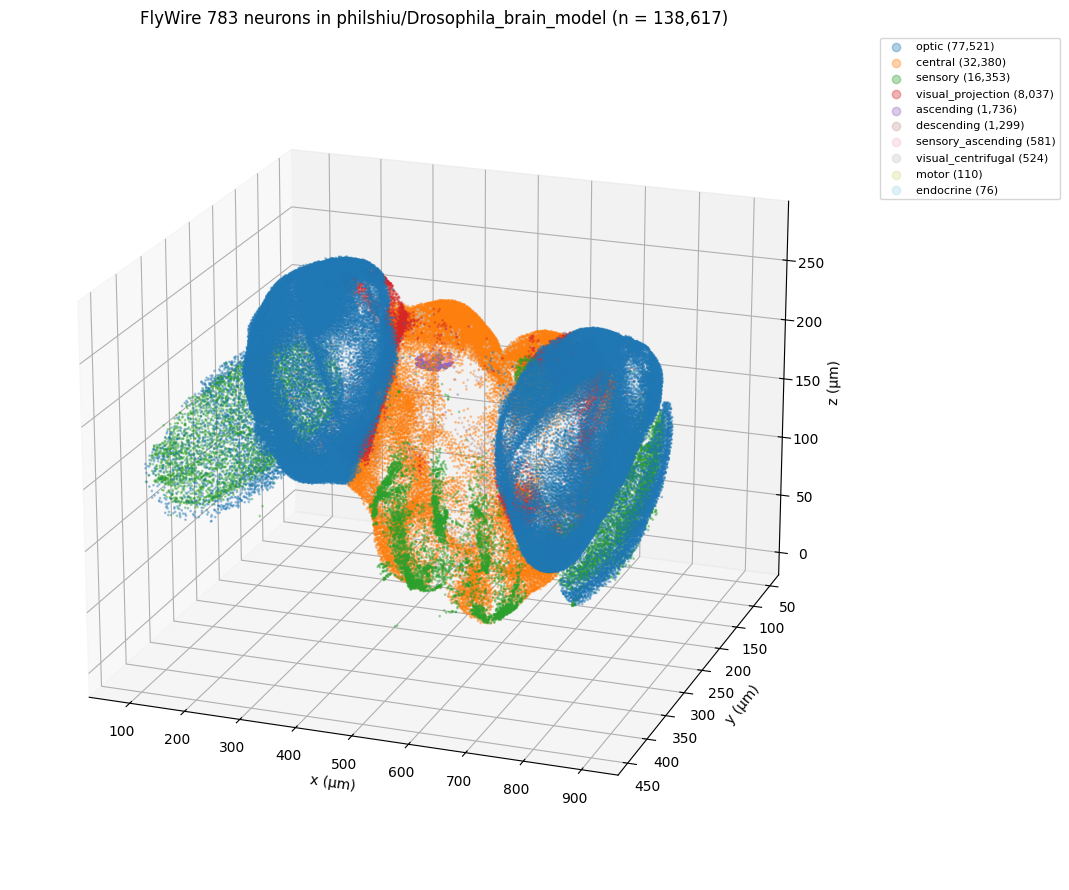

In [4]:
classes = (
    df["super_class"]
    .fillna("unknown")
    .value_counts()
    .index.tolist()
)
palette = plt.get_cmap("tab20")(np.linspace(0, 1, len(classes)))
colour_for = dict(zip(classes, palette, strict=True))

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

for cls in classes:
    sub = df[df["super_class"].fillna("unknown") == cls]
    ax.scatter(
        sub["x_um"], sub["y_um"], sub["z_um"],
        s=1, alpha=0.35, color=colour_for[cls], label=f"{cls} ({len(sub):,})",
    )

ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_zlabel("z (µm)")
ax.set_title(f"FlyWire 783 neurons in philshiu/Drosophila_brain_model (n = {len(df):,})")
ax.invert_yaxis()  # FlyWire/FAFB convention: dorsal up
ax.view_init(elev=20, azim=-70)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), markerscale=6, fontsize=8)
fig.tight_layout()
plt.show()

## Orthogonal projections

Three 2D views are easier to read than a single 3D angle when the cloud is this dense.

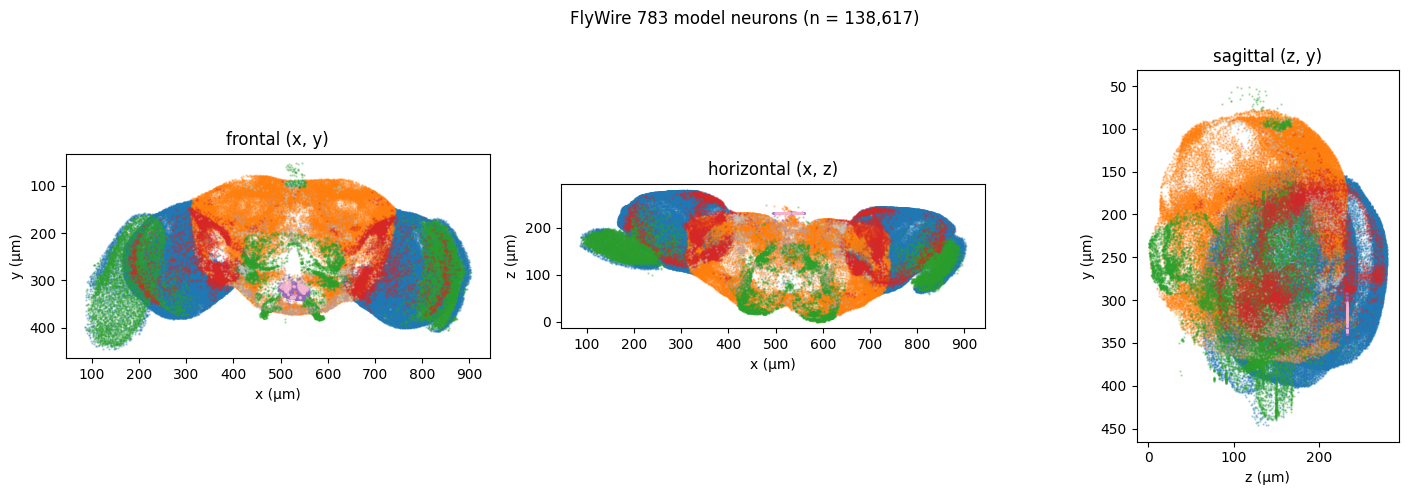

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (a, b, title) in zip(
    axes,
    [("x_um", "y_um", "frontal (x, y)"),
     ("x_um", "z_um", "horizontal (x, z)"),
     ("z_um", "y_um", "sagittal (z, y)")],
    strict=True,
):
    for cls in classes:
        sub = df[df["super_class"].fillna("unknown") == cls]
        ax.scatter(sub[a], sub[b], s=0.5, alpha=0.3, color=colour_for[cls])
    ax.set_xlabel(a.replace("_um", " (µm)"))
    ax.set_ylabel(b.replace("_um", " (µm)"))
    ax.set_title(title)
    ax.set_aspect("equal")
    if b == "y_um":
        ax.invert_yaxis()

fig.suptitle(f"FlyWire 783 model neurons (n = {len(df):,})")
fig.tight_layout()
plt.show()

## Optional: interactive plotly view

Skip this cell if `plotly` is not installed. With it you can rotate / zoom / hover.

In [6]:
try:
    import plotly.express as px

    sample = df.sample(min(40_000, len(df)), random_state=0)
    fig = px.scatter_3d(
        sample,
        x="x_um", y="y_um", z="z_um",
        color=sample["super_class"].fillna("unknown"),
        hover_data=["root_id", "side", "top_nt"],
        opacity=0.5,
    )
    fig.update_traces(marker={"size": 1.5})
    fig.update_layout(
        height=750,
        scene={"yaxis": {"autorange": "reversed"}, "aspectmode": "data"},
    )
    fig.show()
except ImportError:
    print("plotly not installed; run `uv pip install plotly` to enable this cell")

plotly not installed; run `uv pip install plotly` to enable this cell


## Export the joined coordinates

Saves `model_neuron_coordinates_783.csv` next to the cached data so the table can be reused outside the notebook.

In [7]:
out = CACHE / "model_neuron_coordinates_783.csv"
df[["root_id", "x_um", "y_um", "z_um", "super_class", "side", "top_nt"]].to_csv(out, index=False)
print(f"wrote {out} ({out.stat().st_size / 1e6:.1f} MB, {len(df):,} rows)")

wrote /Users/james/.cache/flywire_783/model_neuron_coordinates_783.csv (9.1 MB, 138,617 rows)
